
---

# 📉 **Exponentially Weighted Moving Average (EWMA)**  
aka **Exponential Weighted Average (EWA)**  
*A powerful way to smooth noisy data and track trends over time!*

---

## ✅ **What is EWMA / EWA?**

📌 The **Exponentially Weighted Moving Average (EWMA)** is a technique to calculate a **moving average** of a time series where **recent observations are given more weight** than older ones.

It’s used widely in:

- 📊 **Smoothing loss curves**
- ⚙️ **Optimizers like Adam, RMSProp**
- 🧠 **Batch Normalization (running statistics)**

---

## 🧮 **EWMA Formula**

$
v_t = \beta v_{t-1} + (1 - \beta) \cdot x_t
$

Where:
- $ v_t $: Smoothed value at time $ t $
- $ x_t $: Current value (e.g., gradient, loss)
- $ \beta $: Decay factor (**0 < β < 1**), controls how much weight to give to past vs. recent values

---

### 🧠 Intuition:

- When $ \beta $ is **close to 1** → slow decay → more **stable**, but less responsive  
- When $ \beta $ is **smaller** → fast decay → more **responsive**, but more **noisy**

---

## 🔍 **Why Use EWMA in Deep Learning?**

| Use Case                         | Description |
|----------------------------------|-------------|
| 🎯 **Loss smoothing**            | Visualize training trends (removes noise) |
| 🧮 **Adam/RMSProp Optimizers**    | Track exponentially averaged gradients |
| 🔁 **BatchNorm Running Mean/Var** | Maintain moving stats across mini-batches |
| 🧪 **Trend Detection**           | Smooth performance metrics (e.g., accuracy, reward) |



### 📉 EWMA vs Simple Moving Average (SMA)

| Feature            | EWMA                      | SMA                       |
|--------------------|---------------------------|---------------------------|
| Weighting          | Exponential (recent-heavy) | Equal for all recent points |
| Responsiveness     | High                      | Slower                    |
| Memory Usage       | Low (just last value)     | Higher (stores full window) |
| Used In Deep Learning? | ✅ Yes                 | ❌ Rarely                  |





## ⚙️ **Example: EWMA for Loss Smoothing**

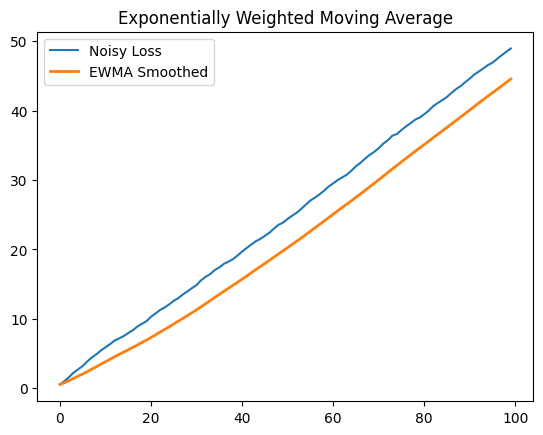

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated noisy loss
np.random.seed(42)
loss = np.cumsum(np.random.randn(100) * 0.1 + 0.5)

# EWMA smoothing
def ewma(series, beta):
    smoothed = []
    v = 0
    for t, x in enumerate(series):
        v = beta * v + (1 - beta) * x
        smoothed.append(v / (1 - beta**(t+1)))  # Bias correction
    return smoothed

smoothed_loss = ewma(loss, beta=0.9)

# Plot
plt.plot(loss, label='Noisy Loss')
plt.plot(smoothed_loss, label='EWMA Smoothed', linewidth=2)
plt.legend()
plt.title("Exponentially Weighted Moving Average")
plt.show()



---

## 📚 **Bias Correction**

In practice, especially at the beginning, the EWMA may **underestimate** values.  
So we apply **bias correction**:

$
\hat{v}_t = \frac{v_t}{1 - \beta^t}
$

✅ Used in **Adam optimizer** to stabilize the initial steps

---

## 🔬 **EWMA in Optimizers (e.g., Adam)**

Adam keeps track of two EWMA terms:

$
m_t = \beta_1 m_{t-1} + (1 - \beta_1)g_t \quad \text{(1st moment)}\\
v_t = \beta_2 v_{t-1} + (1 - \beta_2)g_t^2 \quad \text{(2nd moment)}
$

Then it uses **bias-corrected** versions $ \hat{m}_t $, $ \hat{v}_t $ to update parameters.



## 🧠 Summary

| Term                     | Meaning |
|--------------------------|--------|
| **EWMA**                 | Exponentially Weighted Moving Average |
| **Purpose**              | Smooth recent trends by giving more weight to recent values |
| **Used In**              | Optimizers (Adam, RMSprop), BatchNorm, Visualization |
| **Bias Correction**      | Ensures early steps aren't underestimated |
| **Key Hyperparameter**   | $ \beta $: usually 0.9, 0.99, 0.999 depending on task |


## 🚀 TL;DR

> **EWMA = Memory + Focus**  
> It remembers the past (with decay), but listens more to what’s happening now.

It’s a **small trick with a massive impact** on stability and training performance in deep learning.

---


### **Practice**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/KlrShaK/Delhi-Temperature-Prediction-Time-Series-data/refs/heads/master/daily_temp_dataset/DailyDelhiClimateTest.csv")

In [4]:
df = df[["date","meantemp"]]
df.head()

,date,meantemp
0,2017-01-01,15.913043
1,2017-01-02,18.500000
2,2017-01-03,17.111111
3,2017-01-04,18.700000
4,2017-01-05,18.388889


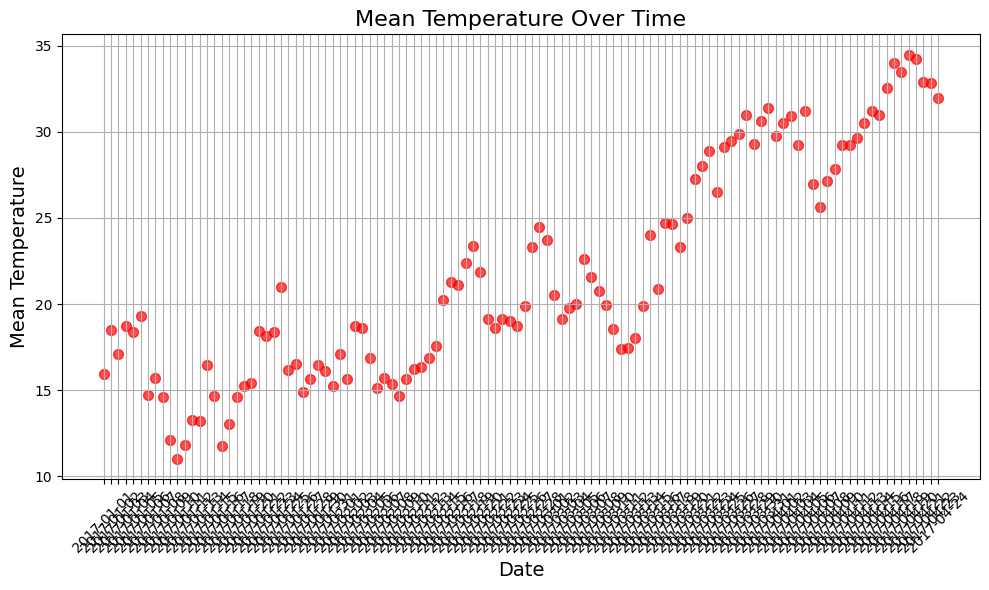

In [5]:
plt.figure(figsize=(10, 6))  # Increase figure size
plt.scatter(df['date'], df['meantemp'], color='red', marker='o', s=50, alpha=0.7)  # Customize marker
plt.title('Mean Temperature Over Time', fontsize=16)  # Add title
plt.xlabel('Date', fontsize=14)  # Add x-axis label
plt.ylabel('Mean Temperature', fontsize=14)  # Add y-axis label
plt.grid(True)  # Add grid
plt.xticks(rotation=45)  # Rotate x-ticks for better readability
plt.tight_layout()  # Adjust layout
plt.show()

In [8]:
x1 = df['meantemp'].ewm(alpha=0.9).mean()
x1

0      15.913043
1      18.264822
2      17.225443
3      18.552677
4      18.405266
         ...    
109    34.403401
110    34.265340
111    33.036534
112    32.891153
113    32.089115
Name: meantemp, Length: 114, dtype: float64

In [9]:
df['ewma'] = x1
df.head()

,date,meantemp,ewma
0,2017-01-01,15.913043,15.913043
1,2017-01-02,18.500000,18.264822
2,2017-01-03,17.111111,17.225443
3,2017-01-04,18.700000,18.552677
4,2017-01-05,18.388889,18.405266


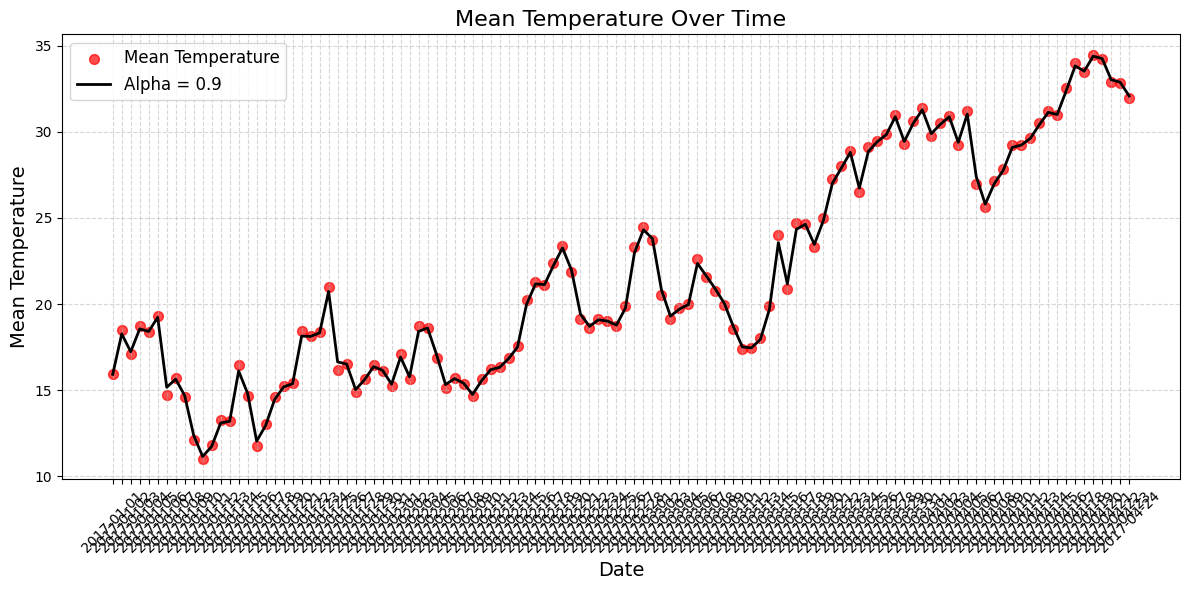

In [10]:
plt.figure(figsize=(12, 6))  # Increase figure size

# Scatter plot
plt.scatter(df['date'], df['meantemp'], color='red', marker='o', s=50, alpha=0.7, label='Mean Temperature')

# Line plot
plt.plot(df['date'], x1, color='black', linewidth=2, label='Alpha = 0.9')

# Adding title and labels
plt.title('Mean Temperature Over Time', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Mean Temperature', fontsize=14)

# Adding grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

# Rotate x-ticks for better readability
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

---